# Optimization for Machine Learning — Tutorial Notebook

This notebook walks through the core optimization concepts covered in the AI for Medicine course.
We will cover:

1. **Convexity** — what makes an optimization problem easy or hard
2. **PyTorch Basics** — tensors, autograd, and linear algebra
3. **Gradient Descent** — the fundamental algorithm
4. **Rate of Convergence** — how fast do algorithms improve?
5. **Stochastic Gradient Descent (SGD) & Adam** — scaling to big data
6. **Accelerated Gradient Descent** — going faster with momentum
7. **Proximal Gradient Descent** — handling non-smooth penalties (Lasso)

---
> **Prerequisites:** basic Python, NumPy familiarity, high-school calculus (derivatives).

In [1]:
# Install / import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Make plots look nice
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
print('Imports done. PyTorch version:', torch.__version__)

Imports done. PyTorch version: 2.5.1


---
## Part 1 — Convexity

### Why does convexity matter?

A function $f$ is **convex** if the line segment between any two points on its graph lies *above* the graph:

$$f\bigl((1-\gamma)x + \gamma y\bigr) \leq (1-\gamma)f(x) + \gamma f(y), \quad \gamma \in [0,1]$$

**Key property:** For a convex function, every local minimum is also a **global minimum**. This is why we love convex problems — gradient-based methods are guaranteed to converge to the best possible solution.

Two important refinements:

| Property | Meaning | Effect on optimization |
|---|---|---|
| **L-smooth** | Gradient doesn't change too quickly | Can use a fixed step size |
| **μ-strongly convex** | Function curves upward at least like a bowl | Unique minimum, faster convergence |

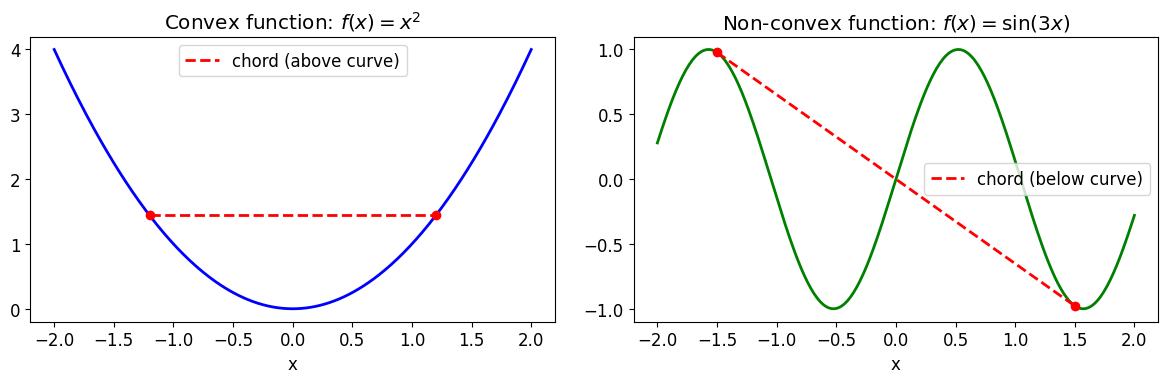

In the non-convex case the chord dips BELOW the curve — so the definition fails.


In [2]:
# --- Visualize convex vs non-convex functions ---

x = np.linspace(-2, 2, 300)

f_convex     = x**2          # convex (bowl shape)
f_nonconvex  = np.sin(3*x)   # non-convex (many local minima)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, f_convex, 'b', linewidth=2)
# Draw the chord between two points to illustrate convexity
x1, x2 = -1.2, 1.2
axes[0].plot([x1, x2], [x1**2, x2**2], 'r--', linewidth=2, label='chord (above curve)')
axes[0].scatter([x1, x2], [x1**2, x2**2], color='red', zorder=5)
axes[0].set_title('Convex function: $f(x) = x^2$')
axes[0].set_xlabel('x'); axes[0].legend()

axes[1].plot(x, f_nonconvex, 'g', linewidth=2)
x1, x2 = -1.5, 1.5
axes[1].plot([x1, x2], [np.sin(3*x1), np.sin(3*x2)], 'r--', linewidth=2, label='chord (below curve)')
axes[1].scatter([x1, x2], [np.sin(3*x1), np.sin(3*x2)], color='red', zorder=5)
axes[1].set_title('Non-convex function: $f(x) = \\sin(3x)$')
axes[1].set_xlabel('x'); axes[1].legend()

plt.tight_layout()
plt.savefig('convexity.png', dpi=100)
plt.show()
print('In the non-convex case the chord dips BELOW the curve — so the definition fails.')

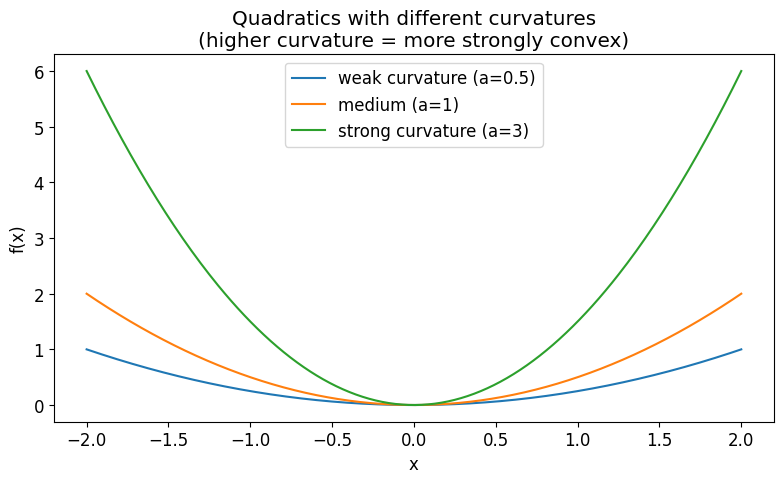

In [3]:
# --- L-smoothness and strong convexity on a quadratic ---
# For f(x) = (a/2)*x^2, the Hessian is 'a'.
# L-smooth means the Hessian <= L*I  =>  a <= L
# mu-strongly convex means Hessian >= mu*I  =>  a >= mu

x = np.linspace(-2, 2, 300)

fig, ax = plt.subplots(figsize=(8, 5))
for a, label in [(0.5, 'weak curvature (a=0.5)'), (1.0, 'medium (a=1)'), (3.0, 'strong curvature (a=3)')]:
    ax.plot(x, 0.5*a*x**2, label=label)

ax.set_title('Quadratics with different curvatures\n(higher curvature = more strongly convex)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — PyTorch Basics

PyTorch is the framework we use to implement and train models. Two key ideas:

1. **Tensors** — multi-dimensional arrays (like NumPy), but can run on GPU
2. **Autograd** — automatic differentiation; PyTorch tracks operations and computes gradients for us

In [4]:
# ---- Tensor creation ----
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3)
c = torch.ones(2, 3)   # 2x3 matrix of ones
d = torch.rand(3, 3)   # random values in [0,1)

print('a:', a)
print('b:', b)
print('c (2x3):\n', c)
print('d (3x3 random):\n', d.round(decimals=3))

a: tensor([1., 2., 3.])
b: tensor([0., 0., 0.])
c (2x3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
d (3x3 random):
 tensor([[0.8820, 0.9150, 0.3830],
        [0.9590, 0.3900, 0.6010],
        [0.2570, 0.7940, 0.9410]])


In [5]:
# ---- Basic operations ----
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

print('x + y =', x + y)          # element-wise addition
print('x * y =', x * y)          # element-wise multiplication
print('dot product x·y =', x @ y)  # dot product

A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
v = torch.tensor([1.0, 1.0])
print('Matrix-vector A@v =', A @ v)

x + y = tensor([5., 7., 9.])
x * y = tensor([ 4., 10., 18.])
dot product x·y = tensor(32.)
Matrix-vector A@v = tensor([3., 7.])


In [6]:
# ---- Autograd: automatic differentiation ----
# We want to compute  d/dx [ f(x) = x^2 ]  at x=3.0
# Analytically: f'(x) = 2x, so f'(3) = 6

x = torch.tensor(3.0, requires_grad=True)  # tell PyTorch to track this variable

f = x ** 2          # define the function
f.backward()        # compute df/dx automatically

print(f'f(x) = x^2 at x=3  →  f(3) = {f.item()}')
print(f'df/dx at x=3  →  x.grad = {x.grad.item()}   (expected: 6.0)')

f(x) = x^2 at x=3  →  f(3) = 9.0
df/dx at x=3  →  x.grad = 6.0   (expected: 6.0)


In [7]:
# ---- Autograd with a multi-variable function ----
# f(x, y) = x^2 + 2*x*y + y^3
# df/dx = 2x + 2y,  df/dy = 2x + 3y^2

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = x**2 + 2*x*y + y**3
f.backward()

print(f'df/dx = {x.grad.item():.2f}  (expected: {2*1 + 2*2:.2f})')
print(f'df/dy = {y.grad.item():.2f}  (expected: {2*1 + 3*4:.2f})')

df/dx = 6.00  (expected: 6.00)
df/dy = 14.00  (expected: 14.00)


### Important: avoid breaking the computational graph

When we manually update parameters (as in gradient descent), we must use `torch.no_grad()` or in-place operations, otherwise PyTorch gets confused.

```python
# WRONG — creates a new tensor, breaks the graph
x = x - lr * x.grad

# CORRECT — update in-place without tracking
with torch.no_grad():
    x -= lr * x.grad
```

---
## Part 3 — Gradient Descent

The most fundamental optimization algorithm. Idea:

> At each step, move in the **direction of steepest descent** (negative gradient).

$$x_{t+1} = x_t - \eta_t \nabla f(x_t)$$

- $\eta_t$ is the **learning rate** (step size) — controls how big a step we take
- **Convergence rate:** for a convex, L-smooth function, $f(x_t) - f(x^*) \leq \frac{2L\|x_0 - x^*\|^2}{t}$ — this is $O(1/t)$

In [8]:
# ---- Simple gradient descent on f(x) = x^2 ----
# Minimum is at x* = 0

def gradient_descent(start, lr, n_steps):
    x = torch.tensor(start, requires_grad=True)
    history = []

    for step in range(n_steps):
        # Forward pass: compute the function value
        f = x ** 2
        history.append((x.item(), f.item()))

        # Backward pass: compute gradient
        f.backward()

        # Parameter update (inside no_grad so PyTorch doesn't track this)
        with torch.no_grad():
            x -= lr * x.grad

        # IMPORTANT: clear gradient before next iteration
        x.grad.zero_()

    return history

history = gradient_descent(start=3.0, lr=0.2, n_steps=20)

xs, fs = zip(*history)
print(f'Start: x={xs[0]:.2f}, f={fs[0]:.2f}')
print(f'End:   x={xs[-1]:.4f}, f={fs[-1]:.6f}')

Start: x=3.00, f=9.00
End:   x=0.0002, f=0.000000


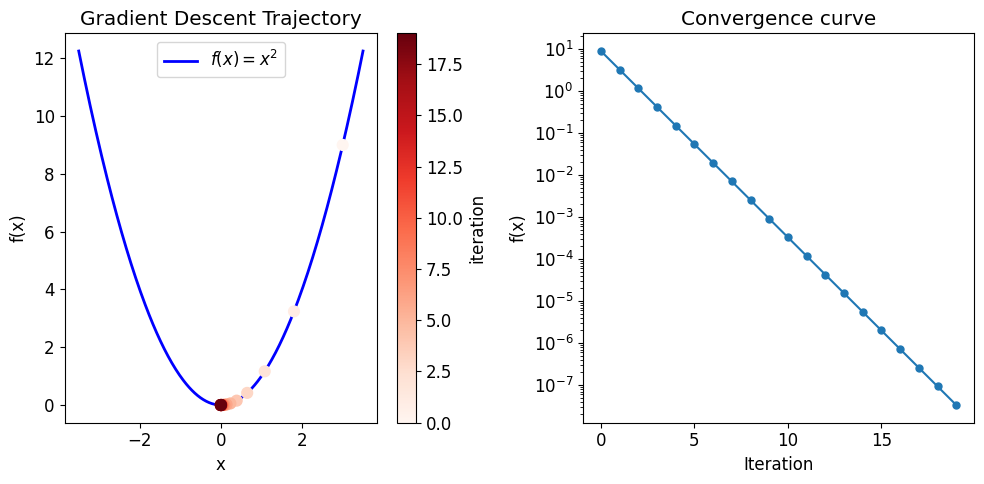

In [9]:
# ---- Visualize the trajectory ----

x_vals = np.linspace(-3.5, 3.5, 300)
f_vals = x_vals ** 2

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x_vals, f_vals, 'b', linewidth=2, label='$f(x)=x^2$')
plt.scatter(xs, fs, c=range(len(xs)), cmap='Reds', zorder=5, s=60)
plt.colorbar(label='iteration')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Gradient Descent Trajectory')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fs, 'o-', markersize=5)
plt.xlabel('Iteration'); plt.ylabel('f(x)')
plt.title('Convergence curve')
plt.yscale('log')

plt.tight_layout()
plt.savefig('gradient_descent.png', dpi=100)
plt.show()

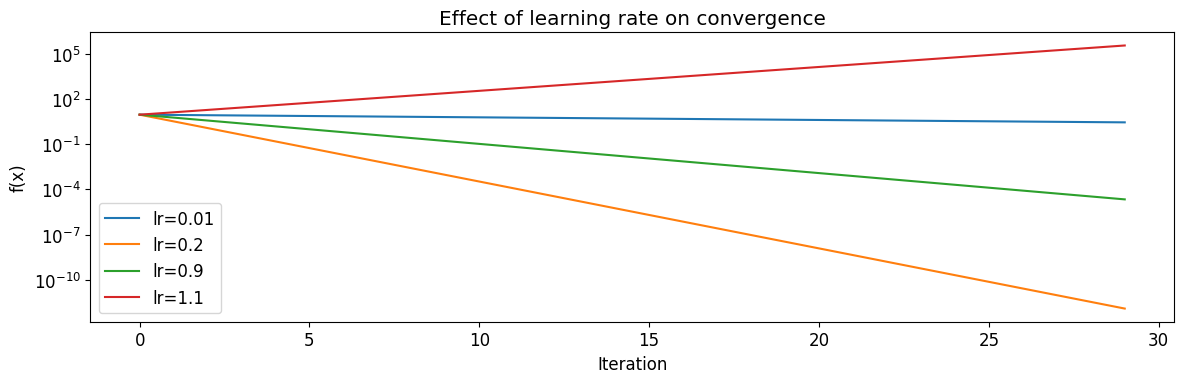

lr=1.1 diverges (loss grows), lr=0.01 is too slow, lr=0.2 is just right.


In [10]:
# ---- Effect of learning rate ----
# Too small → very slow convergence
# Too large → diverges (overshoots)

plt.figure(figsize=(12, 4))
for i, lr in enumerate([0.01, 0.2, 0.9, 1.1]):
    history = gradient_descent(start=3.0, lr=lr, n_steps=30)
    _, fs = zip(*history)
    plt.plot(fs, label=f'lr={lr}')

plt.xlabel('Iteration'); plt.ylabel('f(x)')
plt.title('Effect of learning rate on convergence')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('learning_rate.png', dpi=100)
plt.show()
print('lr=1.1 diverges (loss grows), lr=0.01 is too slow, lr=0.2 is just right.')

### Gradient descent on a 2D problem

On non-symmetric functions, gradient descent can zigzag. Let's see this on

$$f(x_1, x_2) = x_1^2 + 10 x_2^2$$

The condition number is $L/\mu = 10/1 = 10$. The more elongated the bowl, the slower GD converges.

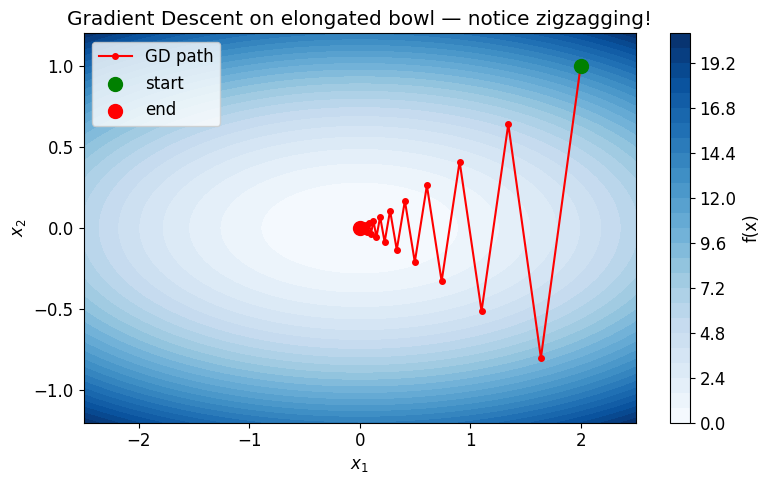

In [11]:
def f_2d(x):
    """f(x1,x2) = x1^2 + 10*x2^2"""
    return x[0]**2 + 10 * x[1]**2

def gradient_descent_2d(start, lr, n_steps):
    x = torch.tensor(start, requires_grad=True)
    path = [x.detach().clone().numpy()]

    for _ in range(n_steps):
        f = f_2d(x)
        f.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
        path.append(x.detach().clone().numpy())

    return np.array(path)

path = gradient_descent_2d([2.0, 1.0], lr=0.09, n_steps=40)

# Contour plot
x1 = np.linspace(-2.5, 2.5, 200)
x2 = np.linspace(-1.2, 1.2, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + 10 * X2**2

plt.figure(figsize=(8, 5))
plt.contourf(X1, X2, Z, levels=30, cmap='Blues')
plt.colorbar(label='f(x)')
plt.plot(path[:, 0], path[:, 1], 'r-o', markersize=4, label='GD path')
plt.scatter(*path[0], color='green', s=100, zorder=5, label='start')
plt.scatter(*path[-1], color='red', s=100, zorder=5, label='end')
plt.title('Gradient Descent on elongated bowl — notice zigzagging!')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.legend()
plt.tight_layout()
plt.savefig('gd_2d.png', dpi=100)
plt.show()

---
## Part 4 — Rate of Convergence

How fast does an algorithm approach the optimal solution? There are four types:

| Type | Error after $k$ steps | Example |
|---|---|---|
| **Sublinear** | $O(1/k)$ | Gradient Descent (convex) |
| **Linear** | $O(c^k)$, $c<1$ | Gradient Descent (strongly convex) |
| **Superlinear** | faster than $c^k$ for any $c<1$ | Quasi-Newton methods |
| **Quadratic** | $O(c^{2^k})$ | Newton's method near optimum |

For machine learning we typically encounter **sublinear** and **linear** convergence.

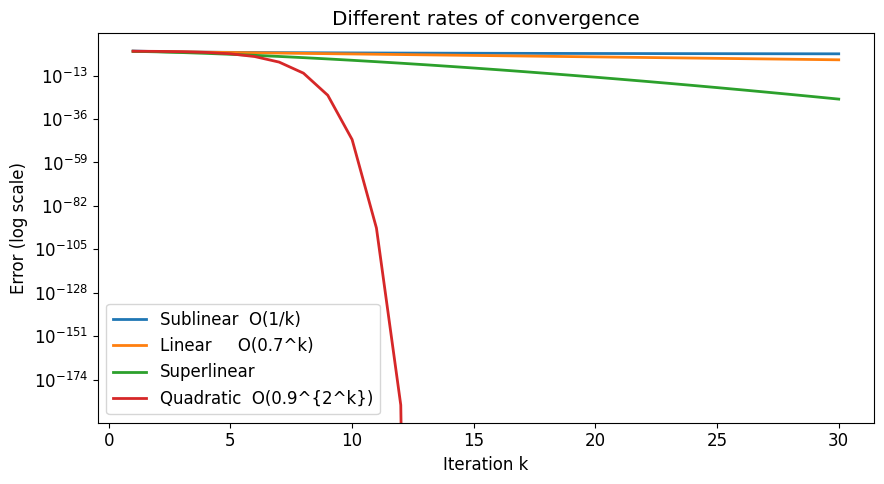

In [12]:
# ---- Visualize different convergence rates ----

k = np.arange(1, 31)

sublinear  = 1 / k              # O(1/k)
linear     = 0.7 ** k           # O(0.7^k)
superlin   = 0.7 ** (k**1.5)    # faster than linear
quadratic  = 0.9 ** (2.0**k)    # O(c^{2^k})

plt.figure(figsize=(9, 5))
plt.plot(k, sublinear,  label='Sublinear  O(1/k)',      linewidth=2)
plt.plot(k, linear,     label='Linear     O(0.7^k)',     linewidth=2)
plt.plot(k, superlin,   label='Superlinear',             linewidth=2)
plt.plot(k, quadratic,  label='Quadratic  O(0.9^{2^k})', linewidth=2)

plt.yscale('log')
plt.xlabel('Iteration k'); plt.ylabel('Error (log scale)')
plt.title('Different rates of convergence')
plt.legend()
plt.tight_layout()
plt.savefig('convergence_rates.png', dpi=100)
plt.show()

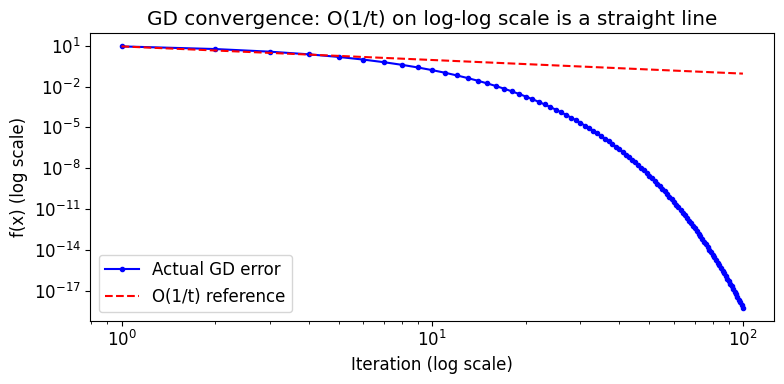

In [13]:
# ---- Verify GD achieves O(1/t) on a convex function ----
# Gradient descent on f(x) = x^2 starting from x=3

history = gradient_descent(start=3.0, lr=0.1, n_steps=100)
_, fs = zip(*history)
fs = np.array(fs)

t = np.arange(1, len(fs) + 1)
theory = fs[0] / t   # O(1/t) reference line

plt.figure(figsize=(8, 4))
plt.loglog(t, fs,      'b-o', markersize=3, label='Actual GD error')
plt.loglog(t, theory,  'r--',               label='O(1/t) reference')
plt.xlabel('Iteration (log scale)'); plt.ylabel('f(x) (log scale)')
plt.title('GD convergence: O(1/t) on log-log scale is a straight line')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 5 — Stochastic Gradient Descent (SGD) and Adam

In machine learning we minimize an **average loss over $n$ samples**:

$$\min_\theta F(\theta) = \frac{1}{n} \sum_{i=1}^n f_i(\theta)$$

Full gradient descent requires computing $n$ gradients per step — expensive when $n$ is large.

**SGD solution:** at each step, pick a random **mini-batch** $B_t$ and use its average gradient:

$$\theta_{t+1} = \theta_t - \frac{\eta_t}{|B_t|} \sum_{i \in B_t} \nabla f_i(\theta_t)$$

**Adam** further improves SGD by adapting the step size for each parameter using gradient history.

In [14]:
# ---- Generate a synthetic regression dataset ----

n_samples = 200
n_features = 5

# True parameters
true_w = torch.tensor([1.5, -2.0, 0.5, 3.0, -1.0])
true_b = torch.tensor(0.8)

X_data = torch.randn(n_samples, n_features)
y_data = X_data @ true_w + true_b + 0.2 * torch.randn(n_samples)  # add small noise

print(f'Dataset: {n_samples} samples, {n_features} features')
print(f'y range: [{y_data.min():.2f}, {y_data.max():.2f}]')

Dataset: 200 samples, 5 features
y range: [-8.93, 10.94]


In [15]:
# ---- Step 1: Create a Dataset class ----
# PyTorch requires a Dataset class with __len__ and __getitem__

class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)         # number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # return one (features, label) pair

dataset    = RegressionDataset(X_data, y_data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f'Number of batches per epoch: {len(dataloader)}')

Number of batches per epoch: 7


In [16]:
# ---- Step 2: Define a simple linear model ----

class LinearModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)  # y = w^T x + b

    def forward(self, x):
        return self.linear(x).squeeze(1)  # output shape: (batch_size,)

model = LinearModel(n_features)
print('Model parameters:')
for name, param in model.named_parameters():
    print(f'  {name}: shape {param.shape}')

Model parameters:
  linear.weight: shape torch.Size([1, 5])
  linear.bias: shape torch.Size([1])


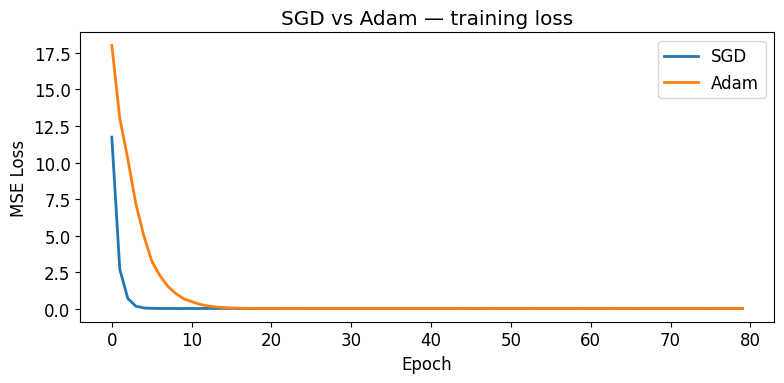

In [17]:
# ---- Step 3: Training loop comparing SGD vs Adam ----

def train_model(optimizer_name, n_epochs=50):
    torch.manual_seed(0)
    model = LinearModel(n_features)
    loss_fn = nn.MSELoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

    epoch_losses = []

    for epoch in range(n_epochs):
        batch_losses = []
        for X_batch, y_batch in dataloader:
            # 1. Forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # 2. Zero gradients (must do before backward!)
            optimizer.zero_grad()

            # 3. Backward pass (compute gradients)
            loss.backward()

            # 4. Update parameters
            optimizer.step()

            batch_losses.append(loss.item())

        epoch_losses.append(np.mean(batch_losses))

    return epoch_losses, model

sgd_losses,  sgd_model  = train_model('SGD',  n_epochs=80)
adam_losses, adam_model = train_model('Adam', n_epochs=80)

plt.figure(figsize=(8, 4))
plt.plot(sgd_losses,  label='SGD',  linewidth=2)
plt.plot(adam_losses, label='Adam', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('SGD vs Adam — training loss')
plt.legend()
plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=100)
plt.show()

In [18]:
# ---- Check recovered weights vs true weights ----
learned_w = adam_model.linear.weight.detach().squeeze().numpy()
learned_b = adam_model.linear.bias.detach().item()

print(f'True weights: {true_w.numpy()}')
print(f'Adam weights: {learned_w.round(3)}')
print(f'True bias:    {true_b.item():.3f}')
print(f'Adam bias:    {learned_b:.3f}')

True weights: [ 1.5 -2.   0.5  3.  -1. ]
Adam weights: [ 1.481 -1.976  0.471  3.012 -1.023]
True bias:    0.800
Adam bias:    0.831


---
## Part 6 — Accelerated Gradient Descent (Momentum)

Standard gradient descent can zigzag because it only looks one step ahead. **Momentum** fixes this by incorporating information from past gradients — like a ball rolling downhill that accumulates speed.

**Nesterov's Accelerated Gradient Descent:**

$$m_{t+1} = \beta_t \, m_t + \eta_t \nabla f(x_t + \beta_t m_t)$$
$$x_{t+1} = x_t - m_{t+1}$$

Key trick: compute the gradient at the **lookahead point** $x_t + \beta_t m_t$ instead of $x_t$.

**Convergence rate:** $O(1/t^2)$ — much faster than GD's $O(1/t)$!

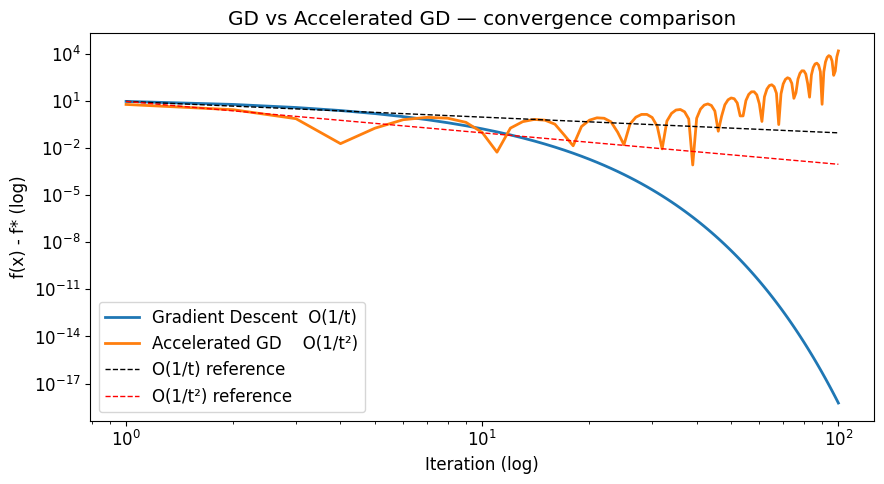

In [19]:
# ---- Accelerated Gradient Descent (Nesterov Momentum) ----

def agd(start, lr, n_steps):
    """Nesterov Accelerated Gradient Descent on f(x) = x^2"""
    x = torch.tensor(start, requires_grad=True)
    m = torch.zeros(1)   # momentum term, starts at 0
    history = []

    for t in range(1, n_steps + 1):
        beta = t / (t + 3.0)   # Nesterov momentum coefficient

        # Lookahead point
        y = x + beta * m
        y = y.detach().requires_grad_(True)

        # Gradient at lookahead
        f = y ** 2
        f.backward()

        # Update momentum and x
        with torch.no_grad():
            m_new = beta * m + lr * y.grad
            x_new = x - m_new
            history.append((x_new.item(), (x_new**2).item()))
            x = x_new.requires_grad_(True)
            m = m_new

    return history

gd_hist  = gradient_descent(start=3.0, lr=0.1, n_steps=100)
agd_hist = agd(start=3.0, lr=0.1, n_steps=100)

_, gd_fs  = zip(*gd_hist)
_, agd_fs = zip(*agd_hist)

t = np.arange(1, 101)
plt.figure(figsize=(9, 5))
plt.loglog(t, gd_fs,            label='Gradient Descent  O(1/t)',   linewidth=2)
plt.loglog(t, agd_fs,           label='Accelerated GD    O(1/t²)', linewidth=2)
plt.loglog(t, 9.0/t,   'k--',  label='O(1/t) reference',           linewidth=1)
plt.loglog(t, 9.0/t**2,'r--',  label='O(1/t²) reference',          linewidth=1)
plt.xlabel('Iteration (log)'); plt.ylabel('f(x) - f* (log)')
plt.title('GD vs Accelerated GD — convergence comparison')
plt.legend()
plt.tight_layout()
plt.savefig('agd_vs_gd.png', dpi=100)
plt.show()

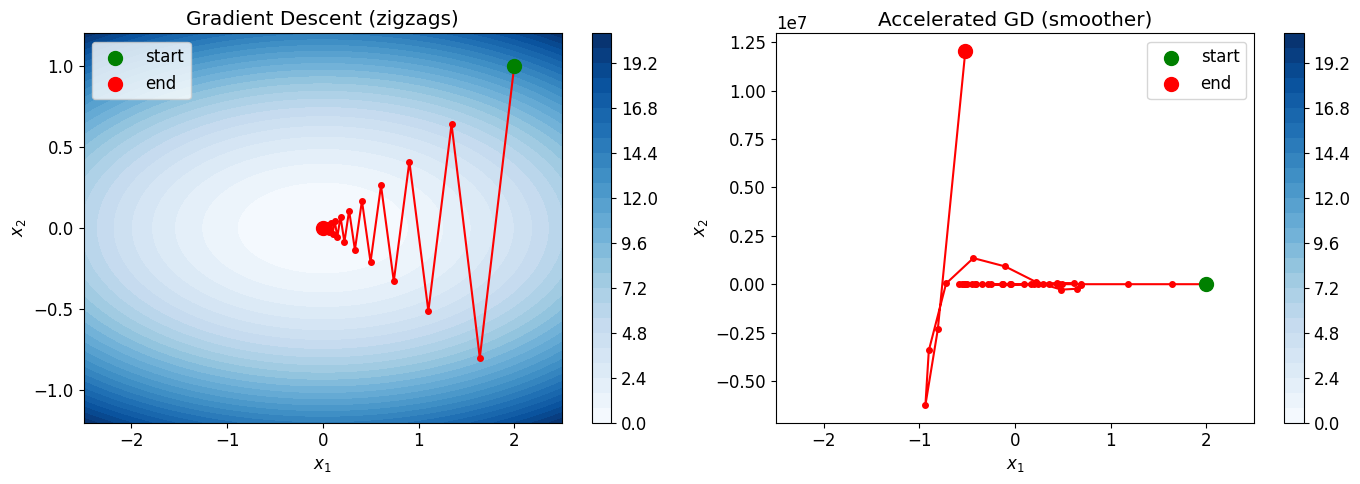

In [20]:
# ---- Show AGD reduces zigzagging on the elongated bowl ----

def agd_2d(start, lr, n_steps):
    x = torch.tensor(start, requires_grad=True)
    m = torch.zeros(2)
    path = [x.detach().clone().numpy()]

    for t in range(1, n_steps + 1):
        beta = t / (t + 3.0)
        y = (x + beta * m).detach().requires_grad_(True)
        f = f_2d(y)
        f.backward()
        with torch.no_grad():
            m_new = beta * m + lr * y.grad
            x_new = (x - m_new)
            path.append(x_new.numpy().copy())
            x = x_new.requires_grad_(True)
            m = m_new
    return np.array(path)

gd_path  = gradient_descent_2d([2.0, 1.0], lr=0.09, n_steps=40)
agd_path = agd_2d([2.0, 1.0], lr=0.09, n_steps=40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes, [gd_path, agd_path], ['Gradient Descent (zigzags)', 'Accelerated GD (smoother)']):
    cf = ax.contourf(X1, X2, Z, levels=30, cmap='Blues')
    plt.colorbar(cf, ax=ax)
    ax.plot(path[:, 0], path[:, 1], 'r-o', markersize=4)
    ax.scatter(*path[0],  color='green', s=100, zorder=5, label='start')
    ax.scatter(*path[-1], color='red',   s=100, zorder=5, label='end')
    ax.set_title(title); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend()

plt.tight_layout()
plt.savefig('agd_2d.png', dpi=100)
plt.show()

---
## Part 7 — Proximal Gradient Descent (handling non-smooth penalties)

Many ML problems have a **composite objective**:

$$\min_x F(x) = \underbrace{f(x)}_{\text{smooth loss}} + \underbrace{h(x)}_{\text{non-smooth penalty}}$$

**Example — Lasso regression:**
$$\min_\beta \underbrace{\frac{1}{2}\|y - X\beta\|_2^2}_{\text{squared error}} + \underbrace{\lambda \|\beta\|_1}_{\ell_1\text{ penalty}}$$

The $\ell_1$ norm is non-smooth (not differentiable at 0), so we cannot just apply gradient descent to $h$.

**Solution — Proximal operator:**

$$\text{prox}_{\eta h}(x) = \arg\min_z \left\{ \frac{1}{2}\|z - x\|_2^2 + \eta h(z) \right\}$$

For $h(x) = \lambda\|x\|_1$, the proximal operator is **soft-thresholding**:

$$\text{SoftThreshold}(x, \tau)_i = \text{sign}(x_i) \cdot \max(|x_i| - \tau,\, 0)$$

**ISTA update rule:**
1. Gradient step on smooth part: $y_t = x_t - \eta \nabla f(x_t)$
2. Proximal step on non-smooth part: $x_{t+1} = \text{SoftThreshold}(y_t,\, \lambda \eta)$

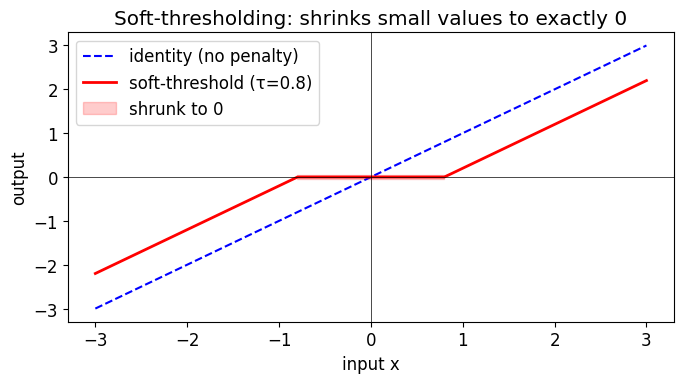

In [21]:
# ---- Visualize soft-thresholding ----

def soft_threshold(x, tau):
    """Soft-thresholding: sets values near 0 exactly to 0 (promotes sparsity)."""
    return torch.sign(x) * torch.clamp(torch.abs(x) - tau, min=0.0)

x_vals = torch.linspace(-3, 3, 200)
tau = 0.8
y_vals = soft_threshold(x_vals, tau)

plt.figure(figsize=(7, 4))
plt.plot(x_vals.numpy(), x_vals.numpy(), 'b--', label='identity (no penalty)', linewidth=1.5)
plt.plot(x_vals.numpy(), y_vals.numpy(), 'r',   label=f'soft-threshold (τ={tau})', linewidth=2)
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.fill_betweenx([-0.05, 0.05], -tau, tau, alpha=0.2, color='red', label='shrunk to 0')
plt.xlabel('input x'); plt.ylabel('output')
plt.title('Soft-thresholding: shrinks small values to exactly 0')
plt.legend()
plt.tight_layout()
plt.savefig('soft_threshold.png', dpi=100)
plt.show()

In [22]:
# ---- ISTA: Iterative Shrinkage Thresholding Algorithm for Lasso ----

def ista_lasso(X, y, lam, lr, n_steps):
    """
    Minimize  (1/2)||y - X*beta||^2 + lam*||beta||_1
    using ISTA (proximal gradient descent).
    """
    n, p = X.shape
    beta = torch.zeros(p)  # start at zero
    losses = []

    for _ in range(n_steps):
        # Gradient of smooth part: grad_f = X^T (X*beta - y) / n
        residual = X @ beta - y
        grad = X.T @ residual / n

        # Gradient step
        beta_half = beta - lr * grad

        # Proximal step (soft-thresholding)
        beta = soft_threshold(beta_half, lam * lr)

        # Track total loss
        loss = 0.5 * (residual ** 2).mean() + lam * beta.abs().sum()
        losses.append(loss.item())

    return beta, losses


# Generate sparse regression data (true beta has only a few non-zero entries)
torch.manual_seed(1)
n, p = 100, 20
X_lasso = torch.randn(n, p)

# True sparse signal: only 3 non-zero coefficients
true_beta = torch.zeros(p)
true_beta[[0, 5, 12]] = torch.tensor([2.0, -3.0, 1.5])
y_lasso = X_lasso @ true_beta + 0.1 * torch.randn(n)

# Fit Lasso with ISTA
lam = 0.1
beta_hat, ista_losses = ista_lasso(X_lasso, y_lasso, lam=lam, lr=0.05, n_steps=500)

print('True beta (first 15 entries):')
print(true_beta[:15].numpy())
print('\nEstimated beta (first 15 entries):')
print(beta_hat[:15].detach().numpy().round(3))

True beta (first 15 entries):
[ 2.   0.   0.   0.   0.  -3.   0.   0.   0.   0.   0.   0.   1.5  0.
  0. ]

Estimated beta (first 15 entries):
[ 1.923 -0.    -0.     0.     0.    -2.898 -0.    -0.    -0.     0.
  0.    -0.     1.43  -0.    -0.   ]


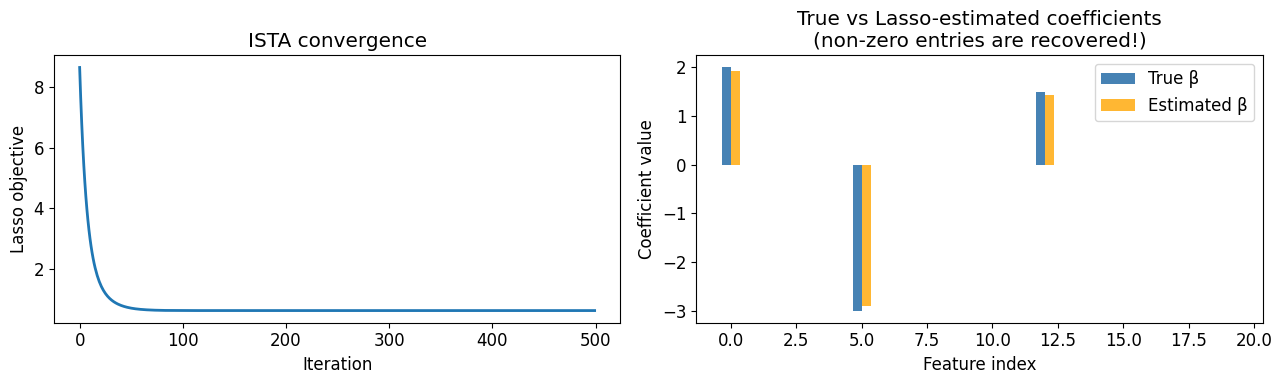

In [23]:
# ---- Plot Lasso results ----

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: convergence
axes[0].plot(ista_losses, linewidth=2)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Lasso objective')
axes[0].set_title('ISTA convergence')

# Right: true vs estimated coefficients
idx = np.arange(p)
width = 0.35
axes[1].bar(idx - width/2, true_beta.numpy(),                  width, label='True β',      color='steelblue')
axes[1].bar(idx + width/2, beta_hat.detach().numpy(), width, label='Estimated β', color='orange', alpha=0.8)
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Coefficient value')
axes[1].set_title('True vs Lasso-estimated coefficients\n(non-zero entries are recovered!)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lasso_ista.png', dpi=100)
plt.show()

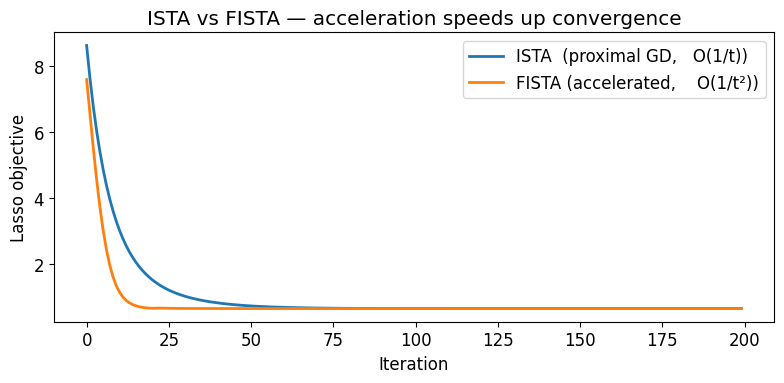

In [24]:
# ---- FISTA: accelerated version of ISTA (O(1/t^2) instead of O(1/t)) ----

def fista_lasso(X, y, lam, lr, n_steps):
    n, p = X.shape
    beta     = torch.zeros(p)
    beta_old = torch.zeros(p)
    t_k      = 1.0         # Nesterov momentum parameter
    losses   = []

    for _ in range(n_steps):
        # Momentum: look ahead using a weighted combination
        z = beta + ((t_k - 1) / (t_k + 1)) * (beta - beta_old)

        # Gradient at the lookahead point z
        residual = X @ z - y
        grad = X.T @ residual / n

        # Save old beta, compute new beta
        beta_old = beta.clone()
        beta = soft_threshold(z - lr * grad, lam * lr)

        # Update momentum coefficient
        t_k = (1 + (1 + 4 * t_k**2)**0.5) / 2

        loss = 0.5 * ((X @ beta - y)**2).mean() + lam * beta.abs().sum()
        losses.append(loss.item())

    return beta, losses

_, ista_losses2  = ista_lasso( X_lasso, y_lasso, lam=lam, lr=0.05, n_steps=200)
_, fista_losses  = fista_lasso(X_lasso, y_lasso, lam=lam, lr=0.05, n_steps=200)

plt.figure(figsize=(8, 4))
plt.plot(ista_losses2,  label='ISTA  (proximal GD,   O(1/t))',   linewidth=2)
plt.plot(fista_losses,  label='FISTA (accelerated,    O(1/t²))', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Lasso objective')
plt.title('ISTA vs FISTA — acceleration speeds up convergence')
plt.legend()
plt.tight_layout()
plt.savefig('ista_vs_fista.png', dpi=100)
plt.show()

---

## 7. Mirror Descent

Mirror descent replaces the L₂ proximal term with a **Bregman divergence**
$$D_\\varphi(x, z) = \\varphi(x) - \\varphi(z) - \\langle\\nabla\\varphi(z), x-z\\rangle$$
allowing the algorithm to adapt to the geometry of the feasible set.

On the probability simplex with KL divergence the update reduces to a **softmax** step:
$$x_{t+1} = \\mathrm{softmax}\\!\\left(-\\tfrac{1}{\\eta_t}\\nabla f(x_t)\\right)$$

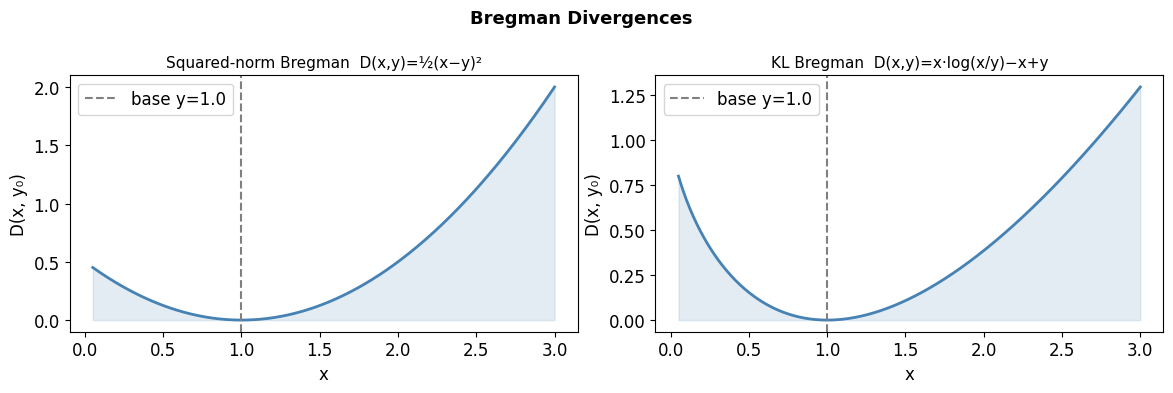

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Visualize Squared-norm vs KL Bregman divergence ----
x = np.linspace(0.05, 3, 400)
y0 = 1.0

D_sq = lambda x, y: 0.5 * (x - y)**2
D_kl = lambda x, y: x * np.log(x / y) - x + y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, D, title in zip(axes,
        [D_sq, D_kl],
        ['Squared-norm Bregman  D(x,y)=½(x−y)²',
         'KL Bregman  D(x,y)=x·log(x/y)−x+y']):
    ax.plot(x, D(x, y0), lw=2, color='steelblue')
    ax.axvline(y0, ls='--', color='gray', label=f'base y={y0}')
    ax.fill_between(x, D(x, y0), alpha=0.15, color='steelblue')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('D(x, y₀)')
    ax.legend()
plt.suptitle('Bregman Divergences', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

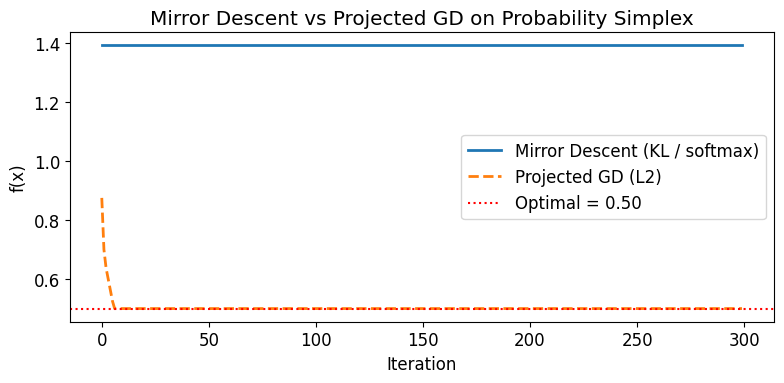

Mirror Descent x: [0.232 0.127 0.269 0.172 0.2  ]
Projected GD   x: [0. 0. 1. 0. 0.]
Optimal: mass on component 2 (c=0.5)


In [26]:
import torch

# ---- Mirror Descent on Probability Simplex vs Projected GD ----
# Minimize f(x) = c^T x  subject to x in Delta_d
torch.manual_seed(0)
d = 5
c = torch.tensor([1.0, 3.0, 0.5, 2.0, 1.5])

def f(x): return (c * x).sum()

def proj_simplex(v):
    u = torch.sort(v, descending=True).values
    cssv = torch.cumsum(u, 0) - 1
    ind  = torch.arange(1, d + 1, dtype=torch.float)
    rho  = ind[u - cssv / ind > 0][-1]
    theta = (torch.cumsum(u, 0)[int(rho)-1] - 1) / rho
    return torch.clamp(v - theta, min=0)

lr = 0.3
losses_md, losses_pgd = [], []

x_md = torch.ones(d) / d
for _ in range(300):
    xv = x_md.detach().requires_grad_(True)
    f(xv).backward()
    with torch.no_grad():
        x_md = torch.softmax(-lr * xv.grad, dim=0)
    losses_md.append(f(x_md).item())

x_pgd = torch.ones(d) / d
for _ in range(300):
    xv = x_pgd.detach().requires_grad_(True)
    f(xv).backward()
    with torch.no_grad():
        x_pgd = proj_simplex(x_pgd - lr * xv.grad)
    losses_pgd.append(f(x_pgd).item())

import matplotlib.pyplot as plt
optimal = c.min().item()
plt.figure(figsize=(8, 4))
plt.plot(losses_md,  label='Mirror Descent (KL / softmax)', lw=2)
plt.plot(losses_pgd, label='Projected GD (L2)', lw=2, ls='--')
plt.axhline(optimal, color='r', ls=':', label=f'Optimal = {optimal:.2f}')
plt.xlabel('Iteration'); plt.ylabel('f(x)')
plt.title('Mirror Descent vs Projected GD on Probability Simplex')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Mirror Descent x: {x_md.detach().numpy().round(3)}')
print(f'Projected GD   x: {x_pgd.detach().numpy().round(3)}')
print(f'Optimal: mass on component {int(c.argmin())} (c={c.min():.1f})')

---

## 8. Nesterov's Smoothing

For non-smooth objectives like the **Square-root Lasso**:
$$\\min_\\beta \\|Y - X\\beta\\|_2 + \\lambda\\|\\beta\\|_1$$
Nesterov's idea: replace $f$ with a smooth surrogate $f_\\mu$ satisfying
$f_\\mu(x) \\le f(x) \\le f_\\mu(x) + \\beta\\mu$,
then apply FISTA on the smooth problem.

**Huber loss** smoothes $|x|$: $h_\\mu(z)=z^2/(2\\mu)$ if $|z|\\le\\mu$, else $|z|-\\mu/2$.

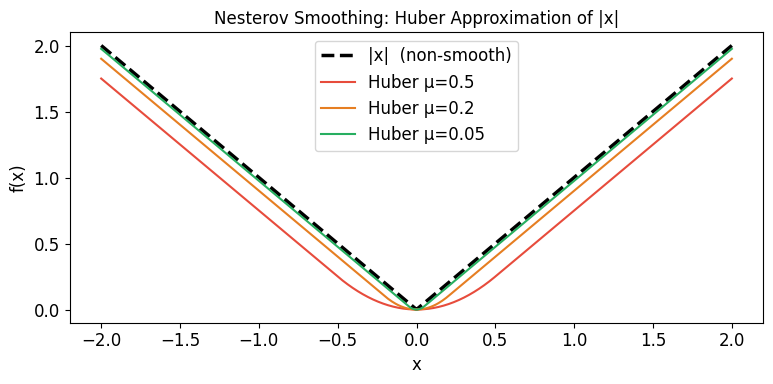

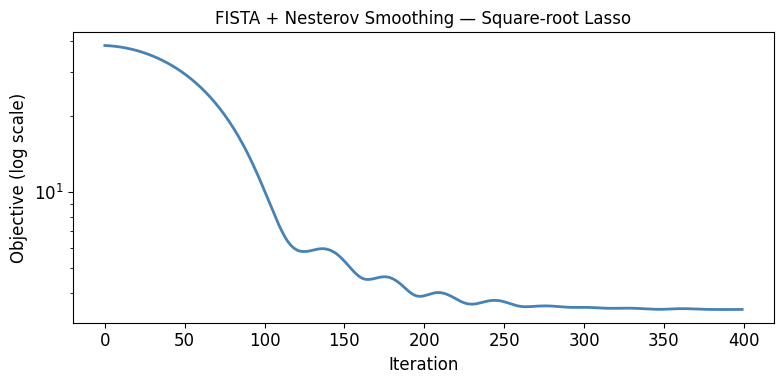

True  β: [ 3.  -2.   1.5 -1.   2.  -1.5]
Estim β: [ 3.09 -2.03  1.53 -0.9   2.04 -1.59]


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Huber smoothing of |x| ----
x = np.linspace(-2, 2, 500)

def huber(x, mu):
    return np.where(np.abs(x) <= mu, x**2 / (2*mu), np.abs(x) - mu/2)

plt.figure(figsize=(8, 4))
plt.plot(x, np.abs(x), 'k--', lw=2.5, label='|x|  (non-smooth)')
for mu, col in zip([0.5, 0.2, 0.05], ['#e74c3c', '#e67e22', '#27ae60']):
    plt.plot(x, huber(x, mu), color=col, label=f'Huber μ={mu}')
plt.title('Nesterov Smoothing: Huber Approximation of |x|', fontsize=12)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.tight_layout(); plt.show()

# ---- FISTA + Nesterov smoothing on Square-root Lasso ----
np.random.seed(42)
n, d = 60, 25
X = np.random.randn(n, d)
beta_true = np.zeros(d); beta_true[:6] = [3., -2., 1.5, -1., 2., -1.5]
Y = X @ beta_true + 0.3 * np.random.randn(n)
lam = 0.15; mu = 0.05

def smooth_l2_val(r, mu):  return np.sqrt(r @ r + mu**2) - mu
def smooth_l2_grad(r, mu): return r / np.sqrt(r @ r + mu**2)
def soft_thresh(v, t):     return np.sign(v) * np.maximum(np.abs(v) - t, 0)

L = np.linalg.norm(X, ord=2)**2 / mu   # Lipschitz constant
beta = np.zeros(d); z = beta.copy(); t_k = 1.0
losses = []
for _ in range(400):
    r = Y - X @ z
    grad = -X.T @ smooth_l2_grad(r, mu)
    beta_new = soft_thresh(z - grad / L, lam / L)
    t_new    = (1 + np.sqrt(1 + 4*t_k**2)) / 2
    z = beta_new + (t_k - 1)/t_new * (beta_new - beta)
    beta, t_k = beta_new, t_new
    losses.append(smooth_l2_val(Y - X @ beta, mu) + lam * np.abs(beta).sum())

plt.figure(figsize=(8, 4))
plt.semilogy(losses, lw=2, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('Objective (log scale)')
plt.title('FISTA + Nesterov Smoothing — Square-root Lasso', fontsize=12)
plt.tight_layout(); plt.show()
print(f'True  β: {beta_true[:6]}')
print(f'Estim β: {beta[:6].round(2)}')

---

## 9. ADMM — Alternating Direction Method of Multipliers

ADMM solves  $\\min f(x)+g(y)$ s.t. $Ax+By=c$  via the **augmented Lagrangian**:
$$x_{t+1}=\\arg\\min_x f(x)+\\tfrac{\\rho}{2}\\|Ax+By_t-c+u_t\\|^2$$
$$y_{t+1}=\\arg\\min_y g(y)+\\tfrac{\\rho}{2}\\|Ax_{t+1}+By-c+u_t\\|^2$$
$$u_{t+1}=u_t+Ax_{t+1}+By_{t+1}-c$$
We demonstrate **Lasso** ($D=I$) and **Fused Lasso** ($D=$ first-difference), using Cholesky pre-factorisation for efficiency.

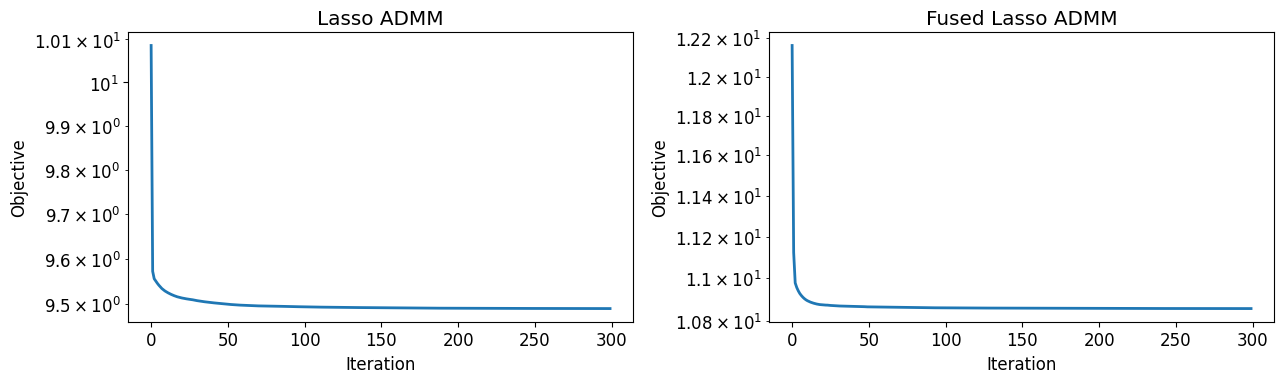

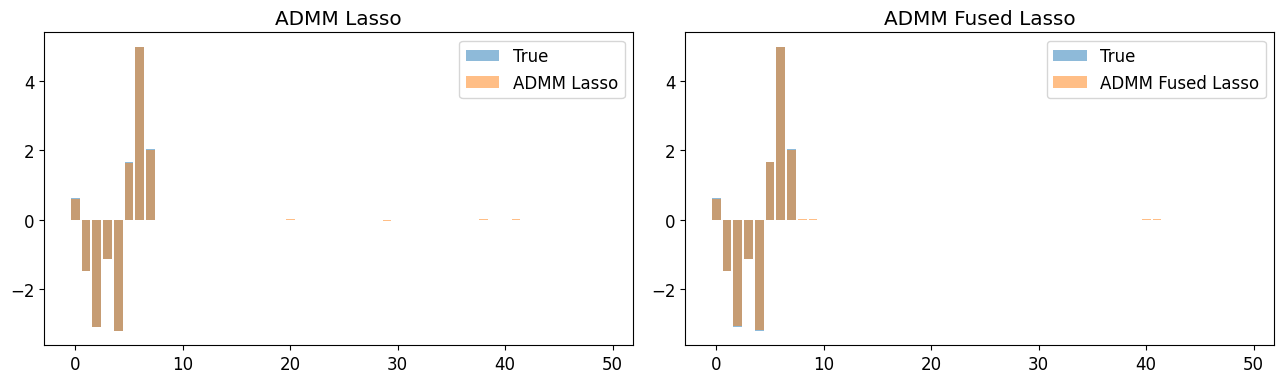

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n, d = 100, 50
X = np.random.randn(n, d)
beta_true = np.zeros(d); beta_true[:8] = np.random.randn(8) * 2
Y = X @ beta_true + 0.1 * np.random.randn(n)
lam = 0.5; rho = 1.0

def soft_thresh(v, t): return np.sign(v) * np.maximum(np.abs(v) - t, 0)
def chol_solve(L, b):
    return np.linalg.solve(L.T, np.linalg.solve(L, b))

# ---- 9.1 Lasso via ADMM (D = I) ----
L_lasso = np.linalg.cholesky(X.T @ X + rho * np.eye(d))
beta_l = np.zeros(d); z_l = np.zeros(d); u_l = np.zeros(d)
losses_lasso = []
for _ in range(300):
    beta_l = chol_solve(L_lasso, X.T @ Y + rho * (z_l - u_l))
    z_l    = soft_thresh(beta_l + u_l, lam / rho)
    u_l   += beta_l - z_l
    losses_lasso.append(0.5*np.sum((Y - X @ beta_l)**2) + lam*np.abs(beta_l).sum())

# ---- 9.2 Fused Lasso via ADMM (D = first-difference) ----
D = np.eye(d)[:-1] - np.eye(d)[1:]          # shape (d-1, d)
L_fused = np.linalg.cholesky(X.T @ X + rho * D.T @ D)
beta_f = np.zeros(d); z_f = np.zeros(d-1); u_f = np.zeros(d-1)
losses_fused = []
for _ in range(300):
    beta_f = chol_solve(L_fused, X.T @ Y + rho * D.T @ (z_f - u_f))
    z_f    = soft_thresh(D @ beta_f + u_f, lam / rho)
    u_f   += D @ beta_f - z_f
    losses_fused.append(0.5*np.sum((Y-X@beta_f)**2) + lam*np.abs(D@beta_f).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(losses_lasso, lw=2); axes[0].set_title('Lasso ADMM')
axes[1].semilogy(losses_fused, lw=2); axes[1].set_title('Fused Lasso ADMM')
for ax in axes: ax.set_xlabel('Iteration'); ax.set_ylabel('Objective')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
idx = np.arange(d)
axes[0].bar(idx, beta_true, alpha=0.5, label='True')
axes[0].bar(idx, beta_l,    alpha=0.5, label='ADMM Lasso'); axes[0].legend()
axes[1].bar(idx, beta_true, alpha=0.5, label='True')
axes[1].bar(idx, beta_f,    alpha=0.5, label='ADMM Fused Lasso'); axes[1].legend()
for ax in axes: ax.set_title(ax.get_legend_handles_labels()[1][1])
plt.tight_layout(); plt.show()

---
## Summary

| Algorithm | Convergence rate | Best used when |
|---|---|---|
| Gradient Descent (GD) | $O(1/t)$ | Smooth convex, small dataset |
| Accelerated GD (AGD) | $O(1/t^2)$ | Smooth convex, faster GD |
| SGD / Adam | varies | Large dataset (mini-batch) |
| Proximal GD (ISTA) | $O(1/t)$ | Non-smooth penalty (Lasso) |
| Accelerated Proximal (FISTA) | $O(1/t^2)$ | Non-smooth + need speed |

### Key take-aways

1. **Convexity** guarantees we find the global optimum — always check if your problem is convex.
2. **Learning rate** is the most important hyperparameter: too small → slow; too large → diverges.
3. **Momentum** reduces zigzagging and achieves faster $O(1/t^2)$ convergence.
4. **Adam** adapts the step size per parameter — robust default choice for deep learning.
5. **Proximal gradient descent** handles non-smooth penalties (like $\ell_1$) via the proximal operator; for Lasso, this is soft-thresholding.
6. **PyTorch autograd** computes gradients automatically — always zero gradients before each backward pass and use `torch.no_grad()` when manually updating parameters.

---
## Exercises

Try these to test your understanding:

1. **Learning rate search**: In Part 3, find the largest learning rate that still converges for $f(x) = x^2$. What happens at learning rate = 2.0?

2. **Condition number**: Change the function in Part 3 (2D) from $x_1^2 + 10x_2^2$ to $x_1^2 + 100x_2^2$ (condition number = 100). Does GD zigzag more?

3. **Lasso sparsity**: In Part 7, try different values of `lam` (e.g., 0.01, 0.5, 1.0). How does the number of non-zero coefficients change with $\lambda$?

4. **PyTorch optimizer**: Replace the manual gradient descent in Part 3 with `torch.optim.SGD`. Compare the results.

5. **Adam vs SGD on a neural network**: Modify the training loop in Part 5 to train a 2-layer neural network (`nn.Sequential(nn.Linear(5,16), nn.ReLU(), nn.Linear(16,1))`). Does Adam still outperform SGD?